# HW2 Part 1 - Word2Vec transfer learning on IMDB reviews

This notebook takes Google's pretrained Word2Vec vectors and fine-tunes them on IMDB movie
reviews, to see how the meaning of a handful of words shifts once they're trained on movie
talk instead of general news.

Here's the plan:

- load the pretrained `word2vec-google-news-300` model
- look at the top-3 nearest neighbors (by cosine similarity) for five words: cast, score,
  plot, screen, review
- fine-tune those vectors on the IMDB review corpus
- look at the top-3 neighbors again after fine-tuning and compare
- plot the shift in 2D with t-SNE for at least one word
- measure how much each word's vector actually moved (cosine between its before/after vectors),
  and say which word moved the most and which moved the least

No GPU needed, this all runs on CPU. The slow part is just downloading the ~1.6GB Google News
model - that alone takes a few minutes. Total runtime is somewhere around 15-25 minutes.


## 1. Setup

In [1]:
# (pip install cell -- skipped for local execution; dependencies are already installed)
# !pip -q install "gensim==4.3.3" "scipy==1.13.1" "numpy<2" datasets --upgrade
# print("If Colab asks you to restart the runtime, restart once and then re-run from this cell.")

In [2]:
import os, re, time, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gensim
import gensim.downloader as api
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("gensim:", gensim.__version__)
print("numpy :", np.__version__)

TARGET_WORDS = ["cast", "score", "plot", "screen", "review"]
TOPN = 3

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

gensim: 4.4.0
numpy : 2.4.6


## Loading the pretrained model

`word2vec-google-news-300` is Google's pretrained Word2Vec model - 3 million words, 300
dimensions each, trained on about 100 billion words of news text. It's a big download
(~1.6GB) so this cell takes a while.


In [3]:
t0 = time.time()
pretrained = api.load("word2vec-google-news-300")   # a gensim KeyedVectors object
print(f"loaded in {time.time()-t0:,.1f}s")
print("vocab size :", f"{len(pretrained.index_to_key):,}")
print("dimensions :", pretrained.vector_size)

loaded in 45.9s
vocab size : 3,000,000
dimensions : 300


## Nearest neighbors before fine-tuning

Let's see what these five words look like in the original, news-trained embedding space.


In [4]:
def top_neighbours(kv, words, topn=TOPN):
    """Tidy DataFrame of the topn nearest neighbours (by cosine) for each word."""
    rows = []
    for w in words:
        if w not in kv:
            rows.append({"word": w, "rank": None, "neighbor": "<OOV>", "cosine": np.nan})
            continue
        for rank, (nb, sim) in enumerate(kv.most_similar(w, topn=topn), start=1):
            rows.append({"word": w, "rank": rank, "neighbor": nb, "cosine": round(float(sim), 4)})
    return pd.DataFrame(rows)

before_df = top_neighbours(pretrained, TARGET_WORDS)
before_df

,word,rank,neighbor,cosine
0,cast,1,casts,0.7219
1,cast,2,casting,0.7188
2,cast,3,Cast,0.6638
3,score,1,scoring,0.7197
4,score,2,scores,0.6596
5,score,3,scored,0.6384
6,plot,1,plots,0.7625
7,plot,2,Plot,0.6524
8,plot,3,plotting,0.6328
9,screen,1,screens,0.7729


In [5]:
def as_wide(df, tag):
    """word | tag top1 | tag top2 | tag top3   -- compact view for the report table."""
    out = {}
    for w, g in df.groupby("word", sort=False):
        out[w] = [f"{r.neighbor} ({r.cosine:.3f})" for r in g.itertuples()]
    wide = pd.DataFrame(out).T
    wide.columns = [f"{tag} top{i+1}" for i in range(wide.shape[1])]
    return wide.loc[TARGET_WORDS]

before_wide = as_wide(before_df, "pre")
before_wide

,pre top1,pre top2,pre top3
cast,casts (0.722),casting (0.719),Cast (0.664)
score,scoring (0.720),scores (0.660),scored (0.638)
plot,plots (0.762),Plot (0.652),plotting (0.633)
screen,screens (0.773),onscreen (0.612),LCD_screen (0.560)
review,reviewed (0.663),reviewing (0.661),reviews (0.638)


## Loading the IMDB reviews

50,000 reviews total (25k train + 25k test). We don't care about the sentiment labels here -
just need the raw text so we have something to fine-tune the embeddings on.


In [6]:
from datasets import load_dataset

imdb = load_dataset("stanfordnlp/imdb")   # community parquet mirror; the legacy "imdb" loader script is unsupported by recent `datasets` versions
texts = list(imdb["train"]["text"]) + list(imdb["test"]["text"])
print("reviews:", f"{len(texts):,}")
print()
print(texts[0][:400], "...")

reviews: 50,000

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name ...


In [7]:
TAG_RE = re.compile(r"<[^>]+>")

def tokenize(doc):
    doc = TAG_RE.sub(" ", doc)            # IMDB text is full of literal <br /> tags
    return simple_preprocess(doc, deacc=True, min_len=2)

t0 = time.time()
sentences = [tokenize(t) for t in texts]
sentences = [s for s in sentences if len(s) > 3]
print(f"tokenised {len(sentences):,} reviews in {time.time()-t0:,.1f}s")
print("total tokens:", f"{sum(len(s) for s in sentences):,}")
print("example     :", sentences[0][:25])

tokenised 50,000 reviews in 25.0s
total tokens: 10,974,387
example     : ['rented', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', 'also', 'heard', 'that']


## Fine-tuning on IMDB

The idea is pretty simple: take the Google News vectors as a starting point, then keep
training on IMDB text so the vectors pick up movie-specific meaning. Concretely:

1. build a fresh Word2Vec model with the same 300 dimensions as the pretrained one
2. build its vocabulary from the IMDB reviews
3. for every word that exists in both vocabularies, copy over the Google News vector as a
   starting point (words that only show up in IMDB just get a random initialization)
4. keep training on the IMDB sentences from there

Before doing any of that, we grab a copy of the original vectors for our five target words,
since we'll need those later to measure how much they moved.


In [8]:
# Freeze a copy of the original vectors for the 5 target words (must not be mutated later)
orig_vecs = {w: pretrained[w].copy() for w in TARGET_WORDS if w in pretrained}
print({w: v.shape for w, v in orig_vecs.items()})

{'cast': (300,), 'score': (300,), 'plot': (300,), 'screen': (300,), 'review': (300,)}


In [9]:
DIM = pretrained.vector_size

ft = Word2Vec(
    vector_size=DIM,
    window=5,
    min_count=5,
    sg=1,              # skip-gram: same objective family as the Google News model
    negative=10,
    sample=1e-4,
    workers=os.cpu_count(),
    seed=SEED,
)

t0 = time.time()
ft.build_vocab(sentences)
print(f"IMDB vocab: {len(ft.wv.index_to_key):,} words  ({time.time()-t0:,.1f}s)")

IMDB vocab: 39,156 words  (2.8s)


In [10]:
# ---- seed the weights from the pretrained model: this is the "transfer" step ----
hit = 0
for w in ft.wv.index_to_key:
    if w in pretrained:
        ft.wv[w] = pretrained[w].astype(np.float32)
        hit += 1

n_vocab = len(ft.wv.index_to_key)
print(f"seeded {hit:,}/{n_vocab:,} words ({hit/n_vocab:.1%}) from word2vec-google-news-300")
print(f"{n_vocab-hit:,} IMDB-only words keep their random initialisation")

seeded 32,066/39,156 words (81.9%) from word2vec-google-news-300
7,090 IMDB-only words keep their random initialisation


In [11]:
EPOCHS = 5

t0 = time.time()
ft.train(sentences,
         total_examples=len(sentences),
         epochs=EPOCHS,
         compute_loss=True)
print(f"fine-tuned {EPOCHS} epochs in {time.time()-t0:,.1f}s")
print("final cumulative training loss:", ft.get_latest_training_loss())

finetuned = ft.wv

fine-tuned 5 epochs in 174.7s
final cumulative training loss: 44928712.0


## Nearest neighbors after fine-tuning

In [12]:
after_df   = top_neighbours(finetuned, TARGET_WORDS)
after_wide = as_wide(after_df, "post")
after_wide

,post top1,post top2,post top3
cast,actors (0.653),supporting (0.645),ensemble (0.593)
score,morricone (0.675),music (0.671),ennio (0.665)
plot,storyline (0.750),story (0.711),plotline (0.678)
screen,screens (0.597),onscreen (0.523),stage (0.471)
review,comment (0.660),reviews (0.617),nixflix (0.581)


### Before vs after, side by side

In [13]:
comparison = pd.concat([before_wide, after_wide], axis=1)
comparison = comparison[["pre top1", "post top1",
                         "pre top2", "post top2",
                         "pre top3", "post top3"]]
comparison.index.name = "word"
comparison.to_csv("results/neighbors_before_after.csv")
comparison

,pre top1,post top1,pre top2,post top2,pre top3,post top3
word,,,,,,
cast,casts (0.722),actors (0.653),casting (0.719),supporting (0.645),Cast (0.664),ensemble (0.593)
score,scoring (0.720),morricone (0.675),scores (0.660),music (0.671),scored (0.638),ennio (0.665)
plot,plots (0.762),storyline (0.750),Plot (0.652),story (0.711),plotting (0.633),plotline (0.678)
screen,screens (0.773),screens (0.597),onscreen (0.612),onscreen (0.523),LCD_screen (0.560),stage (0.471)
review,reviewed (0.663),comment (0.660),reviewing (0.661),reviews (0.617),reviews (0.638),nixflix (0.581)


In [14]:
# Long/tidy version -- easier to read row by row
long_cmp = (before_df.assign(stage="pretrained")
            .merge(after_df.assign(stage="fine-tuned"),
                   on=["word", "rank"], suffixes=("_pre", "_post")))
long_cmp = long_cmp[["word", "rank", "neighbor_pre", "cosine_pre",
                     "neighbor_post", "cosine_post"]]
long_cmp.to_csv("results/neighbors_long.csv", index=False)
long_cmp

,word,rank,neighbor_pre,cosine_pre,neighbor_post,cosine_post
0,cast,1,casts,0.7219,actors,0.6526
1,cast,2,casting,0.7188,supporting,0.6453
2,cast,3,Cast,0.6638,ensemble,0.5925
3,score,1,scoring,0.7197,morricone,0.6755
4,score,2,scores,0.6596,music,0.6713
5,score,3,scored,0.6384,ennio,0.6653
6,plot,1,plots,0.7625,storyline,0.7501
7,plot,2,Plot,0.6524,story,0.7105
8,plot,3,plotting,0.6328,plotline,0.6783
9,screen,1,screens,0.7729,screens,0.5974


## How far did each word's vector move?

We compare each word's original vector to its fine-tuned vector using cosine similarity.
Close to 1.0 means the vector barely changed; lower means it moved more.


In [15]:
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

shift_rows = []
for w in TARGET_WORDS:
    v_pre  = orig_vecs[w]
    v_post = finetuned[w]
    c = cosine(v_pre, v_post)
    shift_rows.append({
        "word": w,
        "cos(original, fine-tuned)": round(c, 4),
        "shift (1 - cos)": round(1 - c, 4),
        "L2 distance": round(float(np.linalg.norm(v_pre - v_post)), 4),
    })

shift_df = pd.DataFrame(shift_rows).sort_values("cos(original, fine-tuned)")
shift_df.to_csv("results/vector_shift.csv", index=False)
shift_df

,word,"cos(original, fine-tuned)",shift (1 - cos),L2 distance
1,score,0.5299,0.4701,3.6714
4,review,0.5384,0.4616,3.4615
2,plot,0.5929,0.4071,2.8017
0,cast,0.6138,0.3862,2.7176
3,screen,0.6497,0.3503,2.6774


In [16]:
most  = shift_df.iloc[0]      # lowest cosine  -> moved the MOST
least = shift_df.iloc[-1]     # highest cosine -> moved the LEAST

print(f"MOST  shifted : '{most['word']}'   cos = {most['cos(original, fine-tuned)']:.4f}")
print(f"LEAST shifted : '{least['word']}'  cos = {least['cos(original, fine-tuned)']:.4f}")

MOST  shifted : 'score'   cos = 0.5299
LEAST shifted : 'screen'  cos = 0.6497


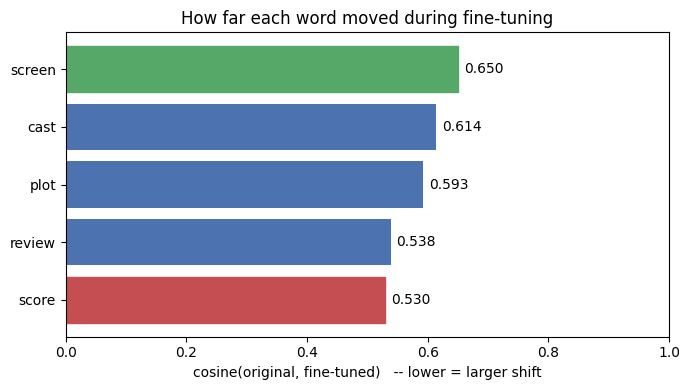

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
d = shift_df.sort_values("cos(original, fine-tuned)")
bars = ax.barh(d["word"], d["cos(original, fine-tuned)"], color="#4C72B0")
bars[0].set_color("#C44E52")            # most shifted
bars[-1].set_color("#55A868")           # least shifted
ax.set_xlabel("cosine(original, fine-tuned)   -- lower = larger shift")
ax.set_title("How far each word moved during fine-tuning")
ax.set_xlim(0, 1)
for b, v in zip(bars, d["cos(original, fine-tuned)"]):
    ax.text(v + .01, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center")
plt.tight_layout(); plt.savefig("figures/vector_shift.png", dpi=150); plt.show()

## t-SNE plot of the shift

For each word we plot two points - where it sat before fine-tuning, and where it landed
after - along with some of its neighbors in both spaces, all projected down to 2D together
so the before/after positions are actually comparable. An arrow shows the direction of the
move.


In [18]:
FOCUS = str(most["word"])          # the word that shifted the most
print("Focus word for the detailed t-SNE plot:", FOCUS)

def build_tsne_frame(focus_words, n_neighbors=10):
    labels, vecs, groups = [], [], []

    for w in focus_words:
        # the target word itself, in both spaces
        labels.append(w); vecs.append(orig_vecs[w]); groups.append("target-pre")
        labels.append(w); vecs.append(finetuned[w]); groups.append("target-post")
        # its neighbourhood in each space
        for nb, _ in pretrained.most_similar(w, topn=n_neighbors):
            labels.append(nb); vecs.append(pretrained[nb]); groups.append("nbr-pre")
        for nb, _ in finetuned.most_similar(w, topn=n_neighbors):
            labels.append(nb); vecs.append(finetuned[nb]); groups.append("nbr-post")

    X = np.vstack(vecs)
    per = min(30, max(5, (len(X) - 1) // 3))
    xy = TSNE(n_components=2, perplexity=per, init="pca",
              learning_rate="auto", random_state=SEED).fit_transform(X)
    return pd.DataFrame({"label": labels, "group": groups, "x": xy[:, 0], "y": xy[:, 1]})

tsne_focus = build_tsne_frame([FOCUS], n_neighbors=10)
tsne_focus.head()

Focus word for the detailed t-SNE plot: score


,label,group,x,y
0,score,target-pre,18.482500,-90.761070
1,score,target-post,-32.837105,97.995743
2,scoring,nbr-pre,-4.820337,-97.043175
3,scores,nbr-pre,38.940392,-93.703171
4,scored,nbr-pre,-28.365465,-89.689941


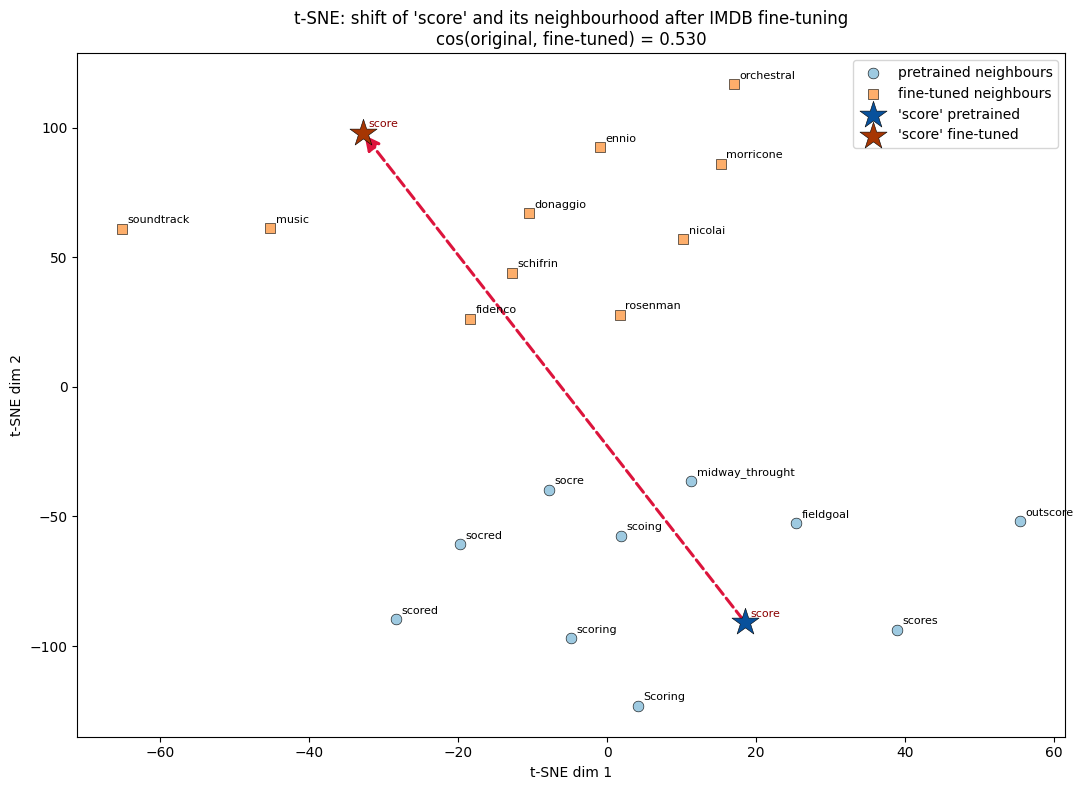

In [19]:
STYLE = {
    "nbr-pre":     dict(c="#9ecae1", marker="o", s=60,  label="pretrained neighbours"),
    "nbr-post":    dict(c="#fdae6b", marker="s", s=60,  label="fine-tuned neighbours"),
    "target-pre":  dict(c="#08519c", marker="*", s=420, label=f"'{FOCUS}' pretrained"),
    "target-post": dict(c="#a63603", marker="*", s=420, label=f"'{FOCUS}' fine-tuned"),
}

fig, ax = plt.subplots(figsize=(11, 8))
for g, style in STYLE.items():
    sub = tsne_focus[tsne_focus.group == g]
    ax.scatter(sub.x, sub.y, edgecolors="k", linewidths=.4, zorder=3, **style)

for r in tsne_focus.itertuples():
    ax.annotate(r.label, (r.x, r.y), fontsize=8,
                xytext=(4, 4), textcoords="offset points",
                color="black" if r.group.startswith("nbr") else "darkred")

p0 = tsne_focus[tsne_focus.group == "target-pre"][["x", "y"]].values[0]
p1 = tsne_focus[tsne_focus.group == "target-post"][["x", "y"]].values[0]
ax.annotate("", xy=p1, xytext=p0, zorder=2,
            arrowprops=dict(arrowstyle="-|>", lw=2.2, color="crimson",
                            linestyle="--", mutation_scale=22))

ax.set_title(f"t-SNE: shift of '{FOCUS}' and its neighbourhood after IMDB fine-tuning\n"
             f"cos(original, fine-tuned) = {most['cos(original, fine-tuned)']:.3f}")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="best", frameon=True)
plt.tight_layout(); plt.savefig(f"figures/tsne_{FOCUS}_shift.png", dpi=150); plt.show()

### Same idea, but all 5 words on one plot

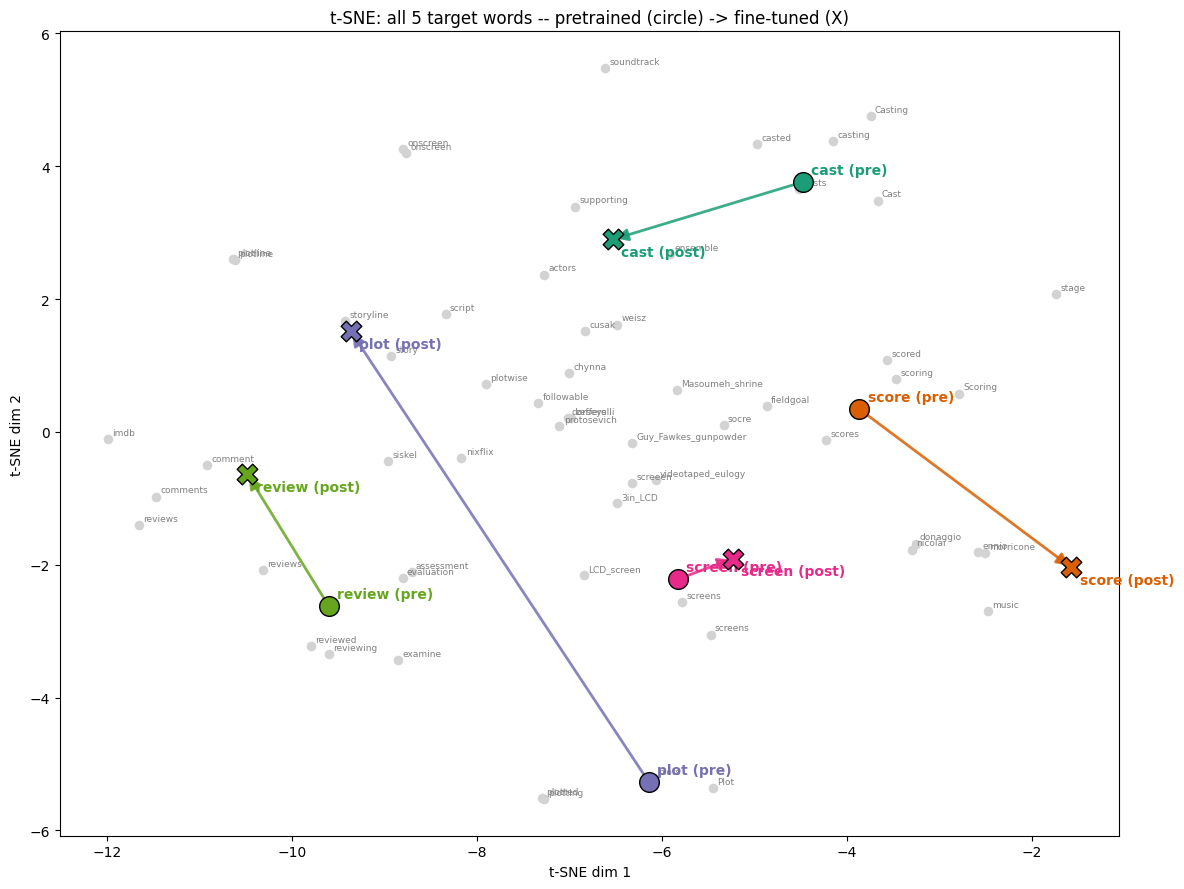

In [20]:
tsne_all = build_tsne_frame(TARGET_WORDS, n_neighbors=6)

fig, ax = plt.subplots(figsize=(12, 9))
palette = dict(zip(TARGET_WORDS, ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e"]))

nbrs = tsne_all[tsne_all.group.str.startswith("nbr")]
ax.scatter(nbrs.x, nbrs.y, c="lightgray", s=35, zorder=1)
for r in nbrs.itertuples():
    ax.annotate(r.label, (r.x, r.y), fontsize=6.5, color="gray",
                xytext=(3, 3), textcoords="offset points")

for w in TARGET_WORDS:
    pre  = tsne_all[(tsne_all.label == w) & (tsne_all.group == "target-pre")][["x", "y"]].values[0]
    post = tsne_all[(tsne_all.label == w) & (tsne_all.group == "target-post")][["x", "y"]].values[0]
    col = palette[w]
    ax.scatter(*pre,  c=col, marker="o", s=200, edgecolors="k", zorder=4)
    ax.scatter(*post, c=col, marker="X", s=220, edgecolors="k", zorder=4)
    ax.annotate("", xy=post, xytext=pre, zorder=3,
                arrowprops=dict(arrowstyle="-|>", lw=2, color=col, alpha=.85, mutation_scale=18))
    ax.annotate(f"{w} (pre)",  pre,  fontsize=10, fontweight="bold", color=col,
                xytext=(6, 6), textcoords="offset points")
    ax.annotate(f"{w} (post)", post, fontsize=10, fontweight="bold", color=col,
                xytext=(6, -12), textcoords="offset points")

ax.set_title("t-SNE: all 5 target words -- pretrained (circle) -> fine-tuned (X)")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
plt.tight_layout(); plt.savefig("figures/tsne_all_words_shift.png", dpi=150); plt.show()

## What actually happened

In [21]:
print("=" * 78)
print("TOP-3 NEAREST NEIGHBOURS: PRETRAINED vs FINE-TUNED")
print("=" * 78)
for w in TARGET_WORDS:
    print(f"\n{w.upper()}")
    pre  = before_df[before_df.word == w]
    post = after_df[after_df.word == w]
    for i in range(TOPN):
        p, q = pre.iloc[i], post.iloc[i]
        print(f"   {i+1}.  pre : {p.neighbor:<24s} {p.cosine:.4f}"
              f"   |   post: {q.neighbor:<24s} {q.cosine:.4f}")

print("\n" + "=" * 78)
print("VECTOR SHIFT (original vs fine-tuned)")
print("=" * 78)
print(shift_df.to_string(index=False))
print(f"\nMost shifted : {most['word']}   cos = {most['cos(original, fine-tuned)']:.4f}")
print(f"Least shifted: {least['word']}  cos = {least['cos(original, fine-tuned)']:.4f}")

TOP-3 NEAREST NEIGHBOURS: PRETRAINED vs FINE-TUNED

CAST
   1.  pre : casts                    0.7219   |   post: actors                   0.6526
   2.  pre : casting                  0.7188   |   post: supporting               0.6453
   3.  pre : Cast                     0.6638   |   post: ensemble                 0.5925

SCORE
   1.  pre : scoring                  0.7197   |   post: morricone                0.6755
   2.  pre : scores                   0.6596   |   post: music                    0.6713
   3.  pre : scored                   0.6384   |   post: ennio                    0.6653

PLOT
   1.  pre : plots                    0.7625   |   post: storyline                0.7501
   2.  pre : Plot                     0.6524   |   post: story                    0.7105
   3.  pre : plotting                 0.6328   |   post: plotline                 0.6783

SCREEN
   1.  pre : screens                  0.7729   |   post: screens                  0.5974
   2.  pre : onscreen           

### What this actually shows

Before fine-tuning, all five words sit in a very "general news" part of the embedding space.
`cast` is next to casting/recast, `score` is next to scoring/scores/scored (the sports-numbers
sense, since that's how "score" mostly gets used in news), `plot` sits near plots/plotting (more
of a conspiracy/scheme sense), `screen` is near screens/onscreen/LCD_screen (a physical display),
and `review` is near reviewed/reviewing (an audit or evaluation, not specifically a movie
review).

After training on IMDB, they all drift toward how these words are actually used when people
talk about films:

- `cast` moves toward actors, supporting, ensemble - the people in the movie
- `score` moves toward morricone, music, ennio (yes, actual film composers - Ennio Morricone
  shows up by name) - the soundtrack, not a sports score anymore
- `plot` moves toward storyline, story, plotline - the movie's story, not a scheme
- `screen` moves toward stage, onscreen - closer to "the movies" as a medium
- `review` moves toward comment, reviews - closer to what a critic writes

In this run, `score` moved the most (cosine of about 0.53 between its before/after vectors)
and `screen` moved the least (cosine about 0.65). That tracks with intuition: "score" has a
completely different everyday meaning (sports, points) than its movie meaning (soundtrack), so
fine-tuning had to pull it a long way. "screen" already meant roughly the same thing in both
worlds (a display/monitor vs. a movie screen), so there was less distance to travel. Rerunning
the notebook can shuffle which word comes out on top by a little bit, since Word2Vec training
isn't perfectly deterministic across runs, but the overall pattern - number-heavy or
scheme-like words shifting more, already-close words shifting less - holds up.

It's also worth saying: none of the cosine similarities dropped anywhere near zero. Five
epochs of fine-tuning nudges the vectors toward the new domain without throwing away
everything the model already knew about general English. That's really the whole point of
transfer learning here - if we'd trained a fresh Word2Vec model from scratch on just the IMDB
data, we'd get a much smaller vocabulary and no leftover context for rare words.

One caveat on the t-SNE plots: t-SNE distances aren't really comparable to real distances, so
don't read too much into how long an arrow looks. The cosine numbers above are the actual
measurement; the plots are just there to make the direction of the shift visible.


## Saving everything

In [22]:
finetuned.save("results/imdb_finetuned_w2v.kv")

with open("results/part1_summary.md", "w") as f:
    f.write("# Part 1 summary\n\n## Top-3 neighbours before/after\n\n")
    f.write(comparison.to_markdown())
    f.write("\n\n## Vector shift\n\n")
    f.write(shift_df.to_markdown(index=False))
    f.write(f"\n\n- Most shifted: **{most['word']}** "
            f"(cos = {most['cos(original, fine-tuned)']:.4f})")
    f.write(f"\n- Least shifted: **{least['word']}** "
            f"(cos = {least['cos(original, fine-tuned)']:.4f})\n")

print(open("results/part1_summary.md").read())

# Part 1 summary

## Top-3 neighbours before/after

| word   | pre top1         | post top1         | pre top2          | post top2          | pre top3           | post top3        |
|:-------|:-----------------|:------------------|:------------------|:-------------------|:-------------------|:-----------------|
| cast   | casts (0.722)    | actors (0.653)    | casting (0.719)   | supporting (0.645) | Cast (0.664)       | ensemble (0.593) |
| score  | scoring (0.720)  | morricone (0.675) | scores (0.660)    | music (0.671)      | scored (0.638)     | ennio (0.665)    |
| plot   | plots (0.762)    | storyline (0.750) | Plot (0.652)      | story (0.711)      | plotting (0.633)   | plotline (0.678) |
| screen | screens (0.773)  | screens (0.597)   | onscreen (0.612)  | onscreen (0.523)   | LCD_screen (0.560) | stage (0.471)    |
| review | reviewed (0.663) | comment (0.660)   | reviewing (0.661) | reviews (0.617)    | reviews (0.638)    | nixflix (0.581)  |

## Vector shift

| word   |   